In [887]:
## Import Packages

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [888]:
### Data Load...

data = pd.read_csv('../bitcoin_data/raw/btc_binance_daily.csv')
data.head()

,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.93351
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.10277
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.43256
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.52187
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.21867


In [889]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

In [890]:
df = data.copy()

In [891]:
### Check duplicate values
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", duplicate_rows.shape[0])
print(duplicate_rows)

Number of duplicate rows: 0
Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


In [892]:
### Check missing values
missing_values = df.isnull().sum()
print("Number of missing values:", missing_values)

Number of missing values: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [893]:
### Statistical overview

summary = df.drop(columns=["date"]).describe().round(3)
print(summary)

             open        high         low       close      volume
count    1000.000    1000.000    1000.000    1000.000    1000.000
mean    77163.065   78527.891   75731.818   77199.740   27660.586
std     24583.530   24836.965   24240.291   24535.328   18602.239
min     26221.680   26397.460   25990.460   26221.670    3104.117
25%     62079.002   63426.162   60653.502   62123.102   15467.079
50%     74020.460   75479.880   73080.750   74020.455   23092.699
75%     96847.298   98288.750   95208.090   96847.300   34445.785
max    124658.540  126199.630  123084.000  124658.540  162065.592


In [894]:
df = df.sort_values("date").reset_index(drop=True)

### Feature Engineering

* Log return

In [895]:
periods = [1, 2, 5, 10]

for p in periods:
    col_name = "log_return" if p == 1 else f"log_return_{p}d"
    df[col_name] = np.log(df["close"] / df["close"].shift(p))

* Lags Feature

In [896]:
lags = [1, 2, 3, 5, 7, 14]

for lag in lags:
    df[f"log_return_lag_{lag}"] = df["log_return"].shift(lag)

* Rolling Return Statistics

In [897]:
return_windows = [3, 7, 14, 30]

for w in return_windows:
    r = df["log_return"].rolling(w)

    df[f"return_mean_{w}d"] = r.mean().shift(1)
    df[f"return_std_{w}d"] = r.std().shift(1)
    #df[f"return_skew_{w}d"] = r.skew().shift(1)
    #df[f"return_kurt_{w}d"] = r.kurt().shift(1)

* Moving Averages Trend Features

In [898]:
ma_windows = [7, 14, 30, 50, 90, 200]

for w in ma_windows:
    df[f"sma_{w}"] = df["close"].rolling(w).mean().shift(1)
    df[f"ema_{w}"] = df["close"].ewm(span=w, adjust=False).mean().shift(1)

    df[f"close_to_sma_{w}"] = (df["close"] - df[f"sma_{w}"]) / df[f"sma_{w}"]
    df[f"close_to_ema_{w}"] = (df["close"] - df[f"ema_{w}"]) / df[f"ema_{w}"]

* RSI

In [899]:
window = 14

delta = df["close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window).mean()
avg_loss = loss.rolling(window).mean()

rs = avg_gain / avg_loss
df["rsi_14"] = (100 - (100 / (1 + rs))).shift(1)

* MACD Features

In [900]:
ema_12 = df["close"].ewm(span=12, adjust=False).mean()
ema_26 = df["close"].ewm(span=26, adjust=False).mean()

df["macd"] = (ema_12 - ema_26).shift(1)
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean().shift(1)
df["macd_hist"] = (df["macd"] - df["macd_signal"]).shift(1)

* Bollinger band Features

In [901]:
w = 20

rolling_mean = df["close"].rolling(w).mean()
rolling_std = df["close"].rolling(w).std()

upper_band = rolling_mean + 2 * rolling_std
lower_band = rolling_mean - 2 * rolling_std

df["bb_width_20"] = ((upper_band - lower_band) / rolling_mean).shift(1)
df["bb_position_20"] = ((df["close"] - lower_band) / (upper_band - lower_band)).shift(1)

* Price Distance

In [902]:
price_windows = [7, 14, 30, 90]

for w in price_windows:
    rolling_high = df["high"].rolling(w).max().shift(1)
    rolling_low = df["low"].rolling(w).min().shift(1)

    df[f"dist_from_high_{w}d"] = (df["close"] - rolling_high) / rolling_high
    df[f"dist_from_low_{w}d"] = (df["close"] - rolling_low) / rolling_low

* Candle pattern features

##### Drop Missing Values

In [903]:
before = len(df)

df_clean = df.dropna().reset_index(drop=True)

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)

Rows before: 1000
Rows after: 800
Rows dropped: 200


##### Target Feature

In [904]:
df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100

In [905]:
# Drop rows where target is missing
df = df.dropna(subset=["target_pct_change"]).reset_index(drop=True)

In [906]:
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (799, 63)


##### Correlation

In [907]:
# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with target_pct_change
corr_with_target = numeric_df.corr()["target_pct_change"].sort_values(ascending=False)

print(corr_with_target)

target_pct_change    1.000000
volume               0.063128
return_std_14d       0.046331
return_std_7d        0.032977
return_std_30d       0.027537
                       ...   
ema_50              -0.051592
ema_90              -0.051951
sma_50              -0.052085
close               -0.052382
log_return_lag_2    -0.071700
Name: target_pct_change, Length: 62, dtype: float64


##### Split the data 

In [908]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

In [909]:
train_df = df.loc[: "2026-01-31"]
test_df = df.loc["2026-02-01" :]

In [910]:
print("Length of training data", len(train_df))
print("Length of test data", len(test_df))

Length of training data 669
Length of test data 130


In [911]:
drop_cols = ["target_pct_change", "open", "close", "high", "low", "volume"]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["target_pct_change"]
y_test = test_df["target_pct_change"]

##### Model

In [912]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##### Hyperparameter Tuning

In [913]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    eval_metric="rmse",
    random_state=42
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "learning_rate": [0.005, 0.01, 0.02, 0.03, 0.05],
    "max_depth": [2, 3, 4],
    "min_child_weight": [3, 5, 7, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.01, 0.05, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 0.5, 1.0],
    "reg_lambda": [1.0, 2.0, 5.0, 10.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best CV RMSE:", -random_search.best_score_)
print("Best parameters:")
print(random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best CV RMSE: 2.3605710047926514
Best parameters:
{'subsample': 0.7, 'reg_lambda': 10.0, 'reg_alpha': 1.0, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 0.05, 'colsample_bytree': 0.7}


In [914]:
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.005,
    max_depth=4,
    min_child_weight=10,
    subsample=0.9,
    colsample_bytree=0.6,
    reg_alpha=1.0,
    reg_lambda=10.0,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",
    gamma = 0.05
)

xgb_reg.fit(
    X_train,
    y_train,
    verbose=100
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [915]:
y_pred = xgb_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

directional_accuracy = np.mean(np.sign(y_pred) == np.sign(y_test))

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Directional Accuracy:", directional_accuracy)

MAE: 2.0457880040645873
RMSE: 2.9175962710285193
R2: -0.13334338103120902
Directional Accuracy: 0.4461538461538462


In [916]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}, index=y_test.index)

comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["abs_error"] = comparison["error"].abs()

print(comparison.head(10))

               actual  predicted      error  abs_error
date                                                  
2026-02-01   2.300170   1.434531   0.865639   0.865639
2026-02-02  -3.769942   1.589512  -5.359454   5.359454
2026-02-03  -3.437208   2.514776  -5.951985   5.951985
2026-02-04 -14.017431   1.638935 -15.656367  15.656367
2026-02-05  12.192683   1.661156  10.531527  10.531527
2026-02-06  -1.828953   1.883556  -3.712510   3.712510
2026-02-07   1.502395   2.032532  -0.530137   0.530137
2026-02-08  -0.273538   2.003114  -2.276652   2.276652
2026-02-09  -1.848798   1.873446  -3.722244   3.722244
2026-02-10  -2.554818   1.729067  -4.283885   4.283885


In [917]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_reg.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
28,close_to_sma_30,0.029374
29,close_to_ema_30,0.023491
23,ema_14,0.023178
33,close_to_ema_50,0.023155
18,sma_7,0.021445
19,ema_7,0.021242
12,return_mean_7d,0.021031
22,sma_14,0.020947
44,macd_signal,0.020759
14,return_mean_14d,0.020551


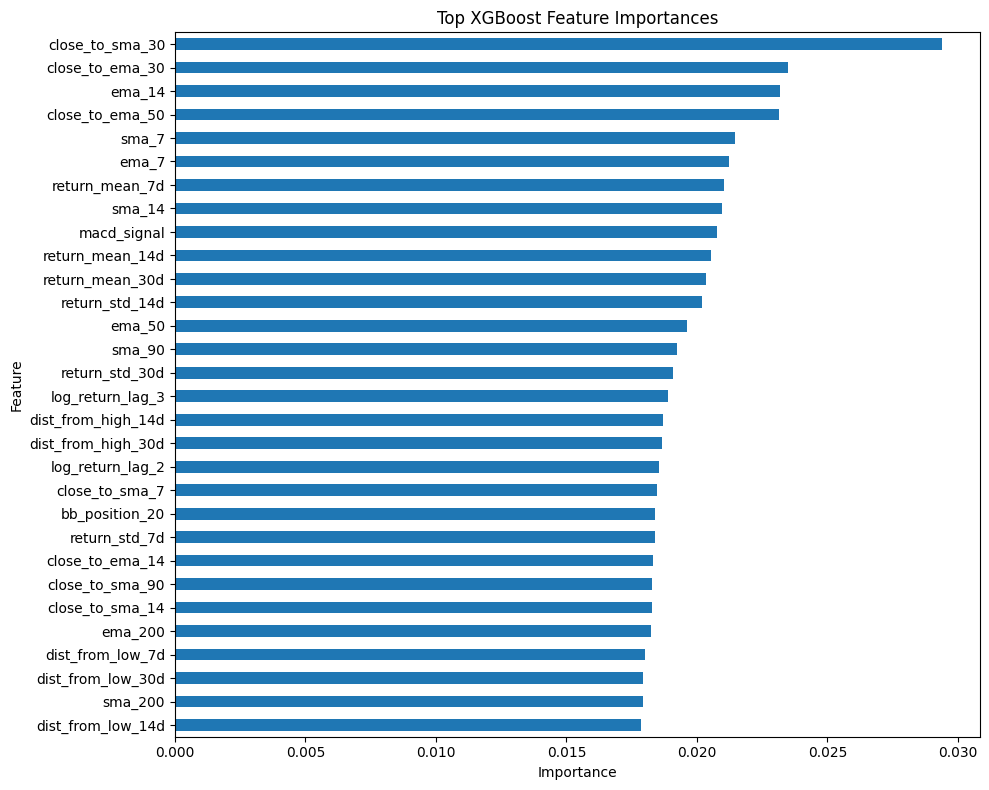

In [918]:
top_n = 30

importance_df.head(top_n).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 8),
    legend=False
)

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

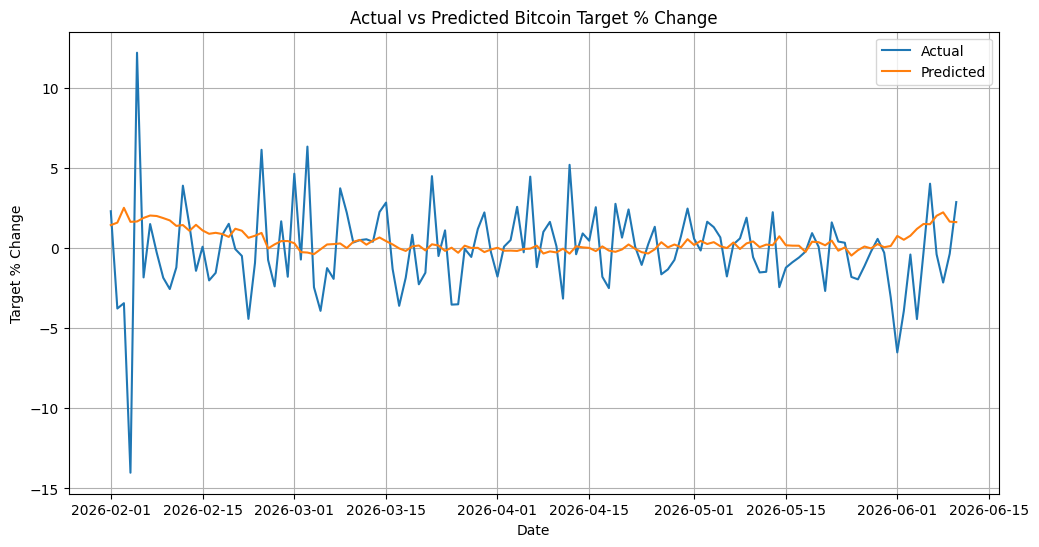

In [919]:
plt.figure(figsize=(12, 6))

plt.plot(comparison.index, comparison["actual"], label="Actual")
plt.plot(comparison.index, comparison["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()